### 2_2 - Train based only  on semantic of query (  Umap )

In [1]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('ds/cleaned_amazon_queries_dataset_en_50k_geo_semant_umap.csv')
cols = ['query' , 'Unnamed: 0' ,'query_chars', 'query_words', 'contains_digit', 'digit_count' , 'avg_word_len' , 'space_count' , 'spec_char_count'] 

#keep only semantic cols
x = data.drop(columns=cols)

In [2]:
x.head(3)

,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14
0,9.971348,6.191277,5.308603,2.536008,4.172568,4.896664,4.411188,4.665093,3.931290,3.995985,4.573812,2.660951,5.258607,6.649301,3.715641
1,10.164223,6.551484,5.090791,4.992197,4.010618,4.146534,4.472170,4.676391,4.897981,3.552489,4.875464,0.991174,5.689204,3.477242,4.564904
2,10.004557,6.528174,5.287583,4.433305,6.600433,3.348886,4.228767,5.053605,4.204326,4.645471,3.953676,1.800899,5.820741,4.941647,2.841812


#### Kmeans

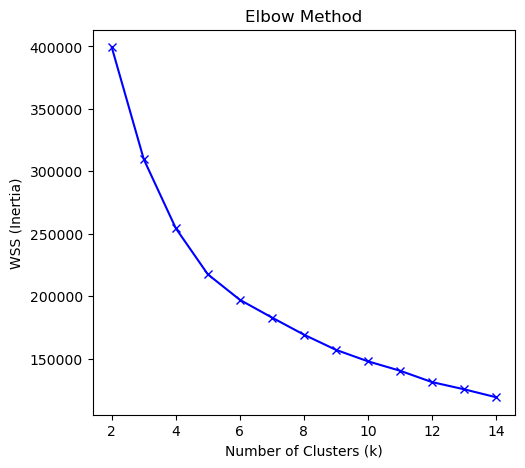

In [3]:
#elbow method to find best k

wss = []
silhouette_avg = []
k_range = range(2, 15) 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(x)
    
    #  WSS for Elbow
    wss.append(kmeans.inertia_)
    

# Plotting the results for your paper
plt.figure(figsize=(12, 5))

# Plot Elbow
plt.subplot(1, 2, 1)
plt.plot(k_range, wss, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WSS (Inertia)')
plt.title('Elbow Method')


plt.show()


#no clear point

In [4]:
#find k based on silhouette_score

import numpy as np

#to make it fast
sample_idx = np.random.choice(len(x), size=5000, replace=False)
x_sample = x.iloc[sample_idx]

for k in range(2, 10, 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(x_sample)
    score = silhouette_score(x_sample, labels)

    print(k, score)

for k in range(20, 200, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    labels = kmeans.fit_predict(x_sample)
    score = silhouette_score(x_sample, labels)

    print(k, score)


# best based on silhouette_score is k = 2

2 0.3054276026068319
3 0.297623879448978
4 0.28255430405668897
5 0.2935126482863315
6 0.3017234010047122
7 0.31897530521196216
8 0.31925628947320295
9 0.31759288281483666
20 0.32886363462310264
30 0.32633950519660065
40 0.3383104372581621
50 0.35343198234108253
60 0.35366141452763405
70 0.3694182183385669
80 0.373312553503004
90 0.36271587228837815
100 0.3813176827111306
110 0.3661951674875818
120 0.3702740227499283
130 0.3677731550804282
140 0.3691291465237954
150 0.373794278685511
160 0.3575485384419901
170 0.3638920439913714
180 0.3721013492774807
190 0.36762719528184484


In [5]:
#Kmeans Model 

kmeans_final = KMeans(n_clusters=80, random_state=41, n_init=10)

# predict
data['kmeans_cluster'] = kmeans_final.fit_predict(x)

# check clusters
print(data['kmeans_cluster'].value_counts())

kmeans_cluster
8     1752
51    1577
14    1218
27    1178
5     1162
      ... 
23     156
21      95
64      76
66      57
60      11
Name: count, Length: 80, dtype: int64


In [6]:
for i in range(80):
    print(f"\n--- Examples of Cluster {i} ---")
    print(data[data['kmeans_cluster'] == i]['query'].head(10).values)


--- Examples of Cluster 0 ---
<StringArray>
[        'primo bottom load',                'ss officer',
                    'llllll',        'checlist manifesto',
                    'nigger',                      'kaws',
             'infinix not 8',                        'sw',
 'b'haystacks pennsylvania'',          'zozoville puzzle']
Length: 10, dtype: str

--- Examples of Cluster 1 ---
<StringArray>
[                                      'minnie womens shirt',
                                              'corpse bride',
                       'suitmeister light up christmas suit',
 'pretty unicorn princess met mermaid make up for halloween',
                                            'mermaid duffle',
                                     'day without a mexican',
                                      'galaxy costume women',
                         'pillowfort magical mermaid sheets',
                                          'lol mermaid doll',
                                  

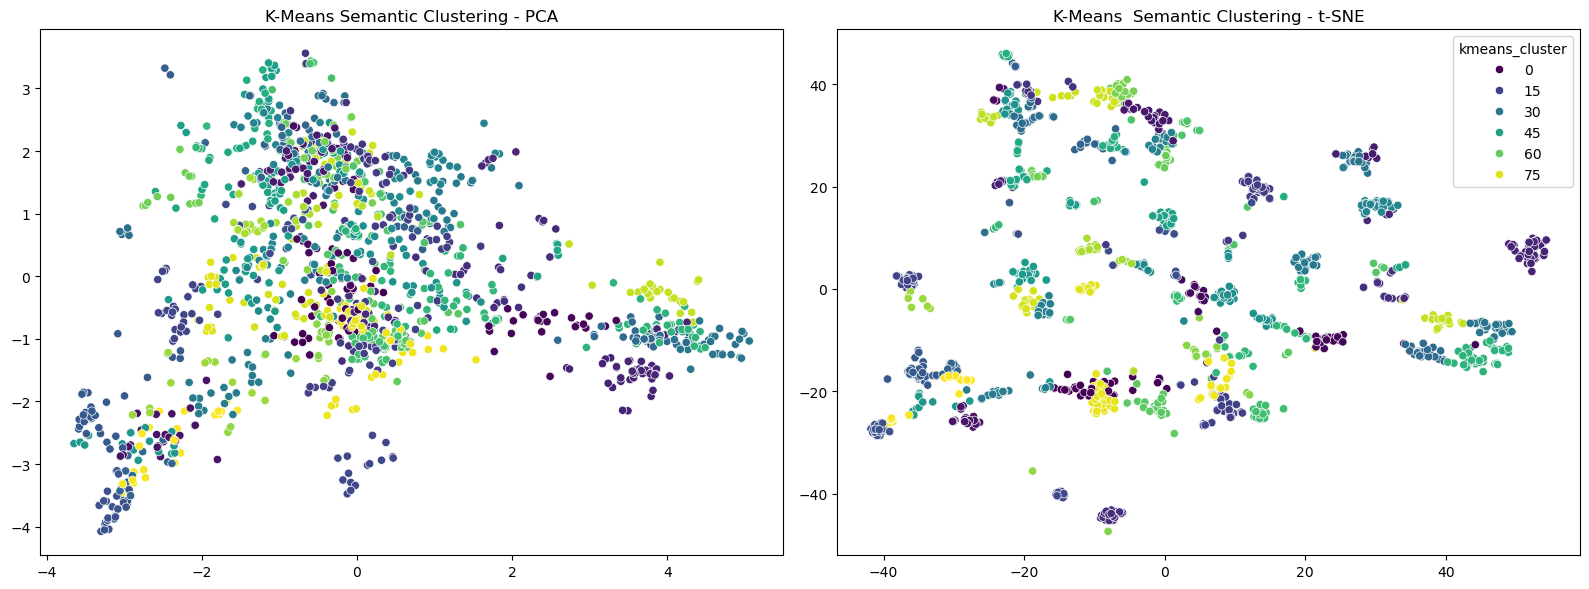

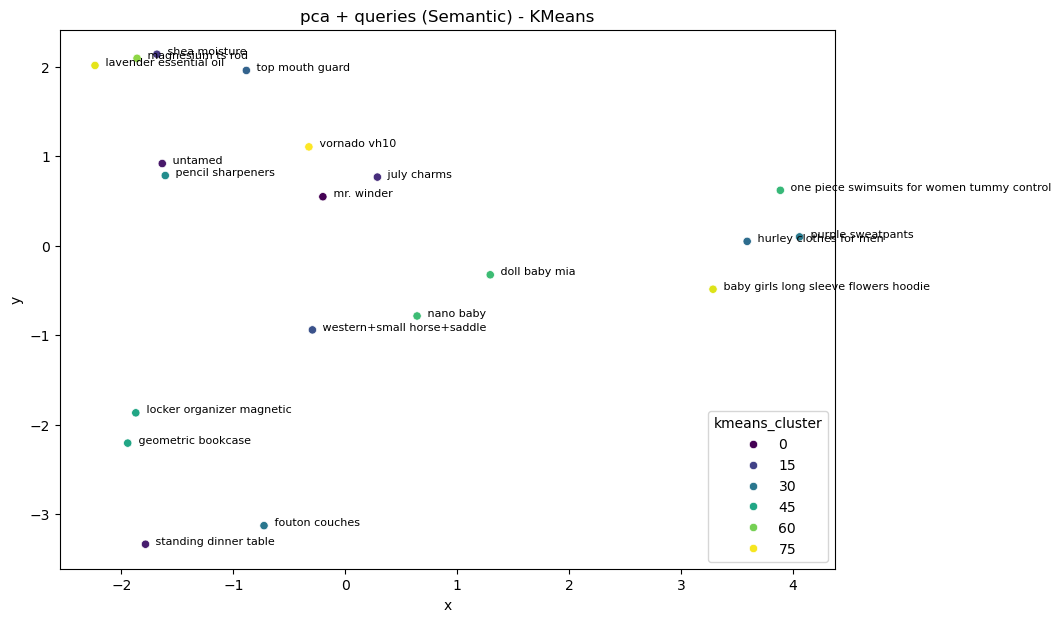

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['kmeans_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    legend=False
)
axes[0].set_title("K-Means Semantic Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("K-Means  Semantic Clustering - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=38)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='kmeans_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['kmeans_cluster'].unique():
    cluster_points = sample[sample['kmeans_cluster'] == cluster].head(8)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries (Semantic) - KMeans")
plt.show()

#### GMM

In [8]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

# Sample for speed
sample_idx = np.random.choice(len(x), size=min(5000, len(x)), replace=False)
x_sample = x.iloc[sample_idx] if hasattr(x, 'iloc') else x[sample_idx]

bic_scores = []
aic_scores = []
K_range = range(5, 101, 5)

for k in K_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=3
    )
    gmm.fit(x_sample)
    bic_scores.append(gmm.bic(x_sample))
    aic_scores.append(gmm.aic(x_sample))
    print(f"K={k}  BIC={gmm.bic(x_sample):.2f}  AIC={gmm.aic(x_sample):.2f}")

K=5  BIC=-7383.46  AIC=-11808.64
K=10  BIC=-51132.26  AIC=-59989.12
K=15  BIC=-71032.55  AIC=-84321.11
K=20  BIC=-87080.08  AIC=-104800.33
K=25  BIC=-99905.04  AIC=-122056.98
K=30  BIC=-109406.06  AIC=-135989.69
K=35  BIC=-114621.85  AIC=-145637.17
K=40  BIC=-121556.41  AIC=-157003.42
K=45  BIC=-123468.02  AIC=-163346.73
K=50  BIC=-129054.33  AIC=-173364.73
K=55  BIC=-130836.12  AIC=-179578.21
K=60  BIC=-129456.51  AIC=-182630.29
K=65  BIC=-132672.20  AIC=-190277.68
K=70  BIC=-132821.12  AIC=-194858.28
K=75  BIC=-134575.36  AIC=-201044.21
K=80  BIC=-135382.31  AIC=-206282.86
K=85  BIC=-135993.19  AIC=-211325.43
K=90  BIC=-135005.50  AIC=-214769.43
K=95  BIC=-136403.27  AIC=-220598.89
K=100  BIC=-135379.50  AIC=-224006.81


In [ ]:


#gmm model
gmm = GaussianMixture(n_components=85, random_state=42)


data['gmm_cluster'] = gmm.fit_predict(x)


In [ ]:
for i in range(85):
    print(f"\n--- GMM Cluster {i} ---")
    print(data[data['gmm_cluster'] == i]['query'].head(8).values)


--- GMM Cluster 0 ---
<StringArray>
[              'gravity falls journal 1,2,3 set',
                     'the north is not enough t',
            'because i could not stop for death',
 'of course your opinion matters just not to me',
                               'yesterday movie',
                           'new years eve movie',
     'looseleaf for interpersonal communication',
                       'psychiatry pocket guide']
Length: 8, dtype: str

--- GMM Cluster 1 ---
<StringArray>
[               'rear rack duke 390', 'someones knocking at the door dvd',
    'hanging pictures without nails',       'modern key hangers for wall',
                   'dummy door knob',           'dummy door handle brass',
                 'f150 tailgateplug',                    'wooden hangers']
Length: 8, dtype: str

--- GMM Cluster 2 ---
<StringArray>
[  'women jogger pants lightweight',               'womens cargo pants',
 'fruit of the loom boxer briefs m',                  'womens overalls',

In [ ]:
# probability 
probs = gmm.predict_proba(x)

data['gmm_confidence'] = probs.max(axis=1)

print(data[['query', 'gmm_cluster', 'gmm_confidence']].head(10))

                                  query  gmm_cluster  gmm_confidence
0                       workout weights           55             1.0
1                   nintendo gift cards           75             1.0
2                         urban skin rx           46             1.0
3                             bird seed           83             1.0
4           +foot cream without alcohol           28             1.0
5  brother tn730 high yield black toner           68             1.0
6                             60 lashes           24             1.0
7                          cpap filters           35             1.0
8         long cord lavalier microphone           36             1.0
9               tumblers bulk wholesale           32             1.0


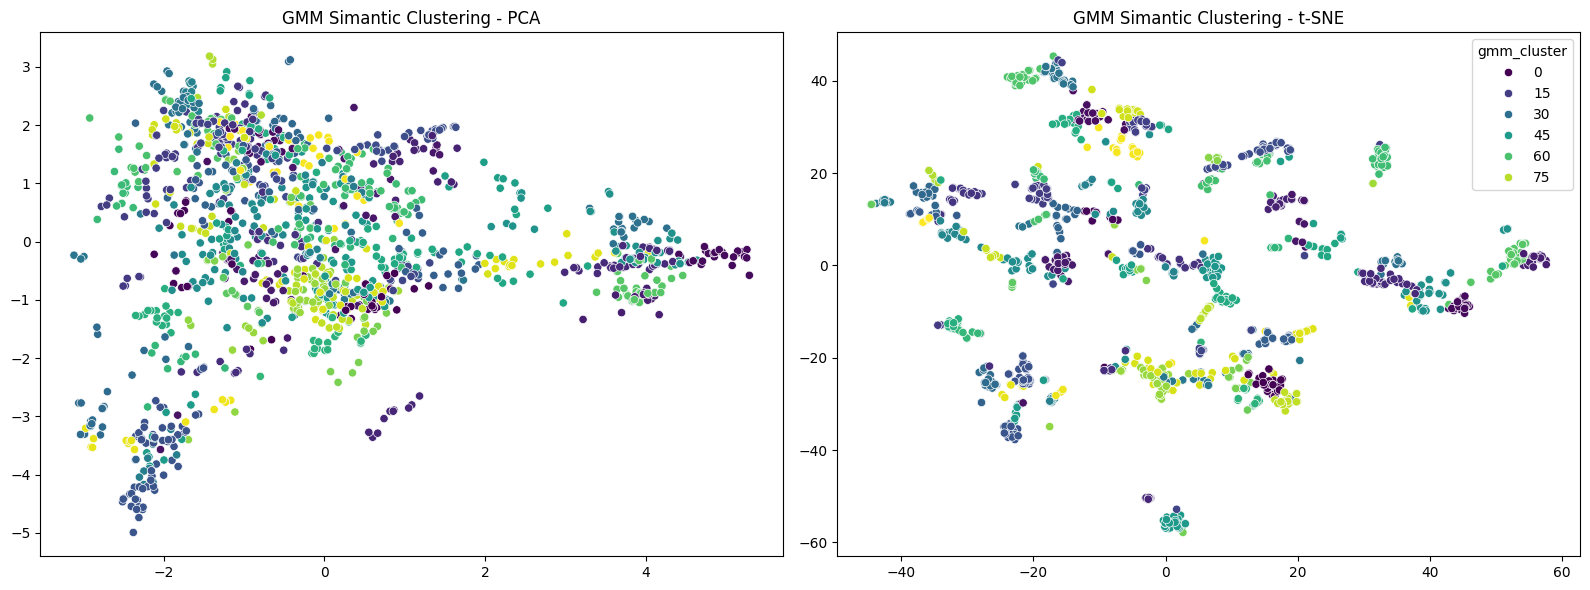

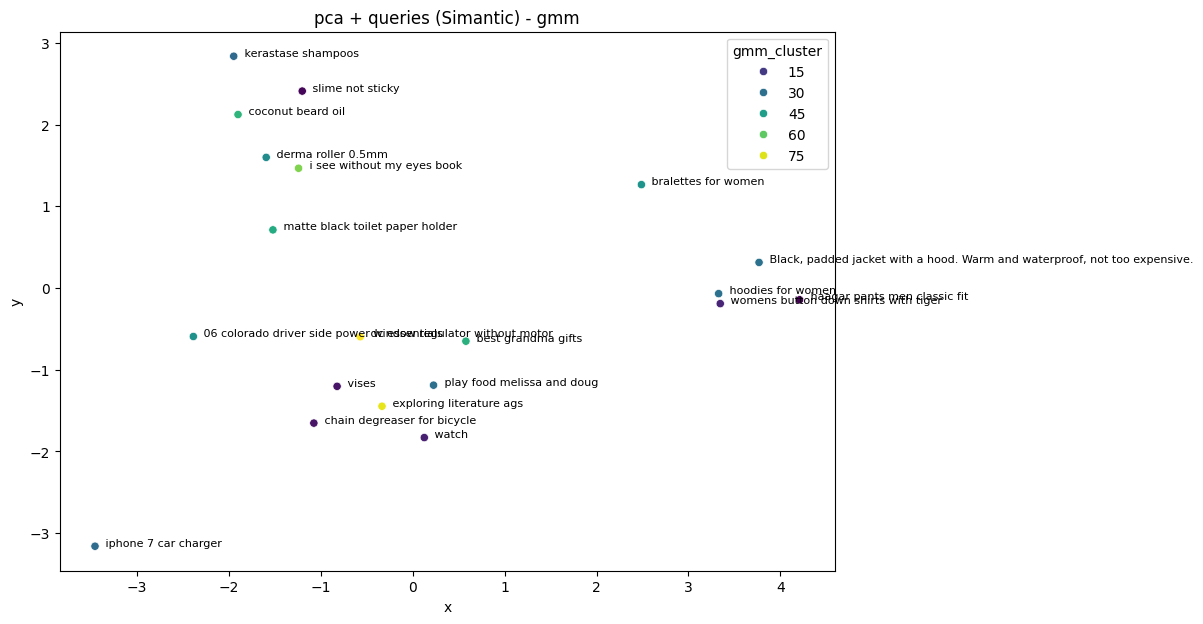

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['gmm_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=41)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    legend=False
)
axes[0].set_title("GMM Semantic Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("GMM Semantic Clustering - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=381)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='gmm_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['gmm_cluster'].unique():
    cluster_points = sample[sample['gmm_cluster'] == cluster].head(6)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries (Semantic) - gmm")
plt.show()

#### DBscan

Suggested eps: 0.5793


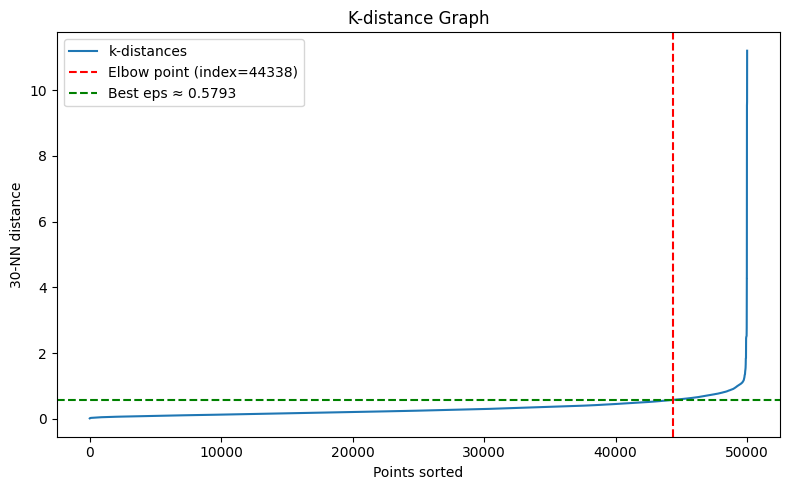

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
from kneed import KneeLocator

k = 30
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(x)
distances, indices = neighbors_fit.kneighbors(x)

distances = np.sort(distances[:, k-1])

# Detect elbow/knee point
kneedle = KneeLocator(
    range(len(distances)), 
    distances, 
    curve="convex", 
    direction="increasing",
    interp_method="polynomial" 
)

best_eps = distances[kneedle.knee]
print(f"Suggested eps: {best_eps:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(distances, label="k-distances")
plt.axvline(x=kneedle.knee, color="red", linestyle="--", label=f"Elbow point (index={kneedle.knee})")
plt.axhline(y=best_eps, color="green", linestyle="--", label=f"Best eps ≈ {best_eps:.4f}")
plt.title("K-distance Graph")
plt.xlabel("Points sorted")
plt.ylabel(f"{k}-NN distance")
plt.legend()
plt.tight_layout()
plt.show()
#

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.4,min_samples=35 , metric='euclidean'
)

labels = dbscan.fit_predict(x)

data['db_cluster'] = labels


print(data['db_cluster'].value_counts())

for c in sorted(data['db_cluster'].unique()):
    print("\n Cluster", c)
    print(data[data['db_cluster'] == c]['query'].head(5).tolist())

db_cluster
-1      7992
 6      5049
 14     4914
 11     3184
 19     2272
        ... 
 127      35
 129      35
 128      26
 133      18
 120      17
Name: count, Length: 135, dtype: int64

 Cluster -1
['carhartt lined cap', 'bronze toilet paper holder', 'new era snapback', 'ironing board', 'black zipties']

 Cluster 0
['workout weights', 'bathroom scale without bluetooth', 'amazon basics weights', 'dumbbells set with rack', 'weights for exercises']

 Cluster 1
['nintendo gift cards', 'christmas cards', 'outdoor things for girls', 'mexican decorations for party', 'nursing graduation gifts']

 Cluster 2
['bird seed', 'pumpkin patch sign', 'sunflower on black and white kitchen', 'backyard seeds', 'grass seed sun']

 Cluster 3
['+foot cream without alcohol', 'japanese sunscreen', 'clinical strength hyaluronic acid', 'neutrogena moisturizer', 'nivea tinted moisturizer']

 Cluster 4
['60 lashes', 'lash tweezers extensions', 'mascara black volume and length waterproof', 'envy magnetic la

C:\Users\hp\AppData\Local\Temp\ipykernel_4924\3108372453.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')


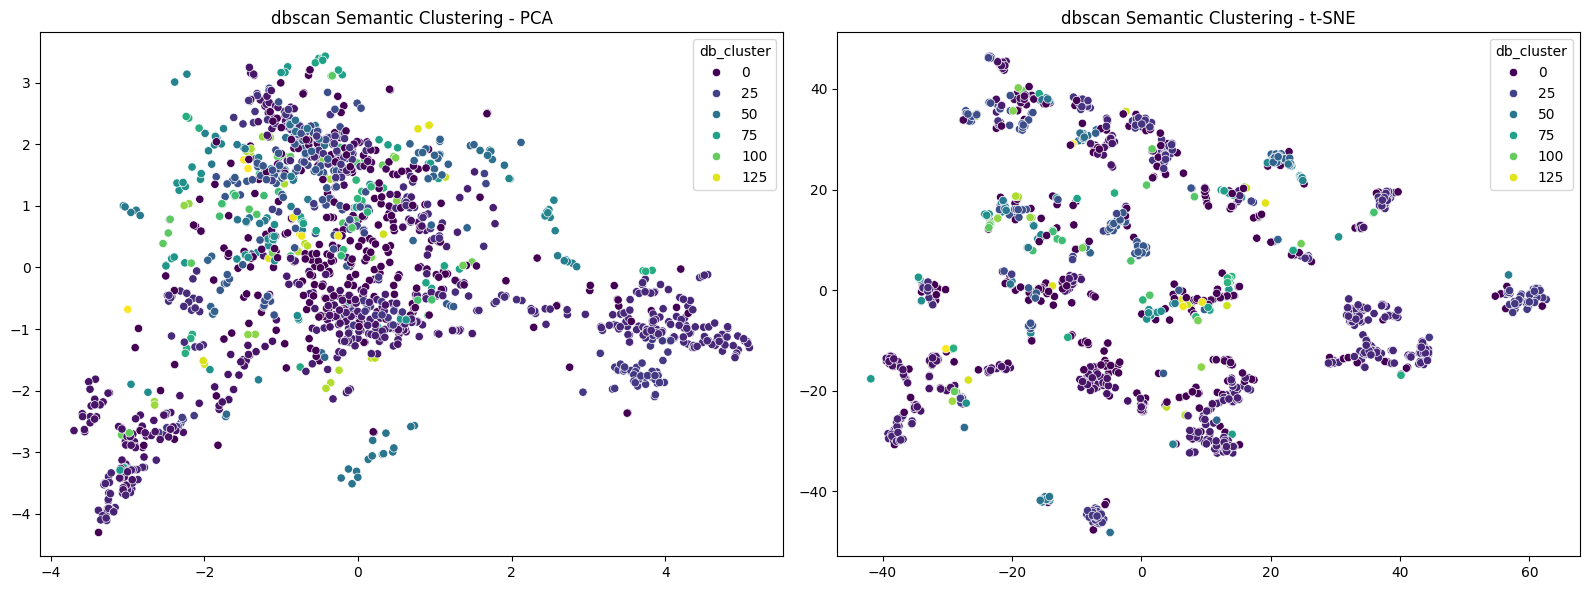

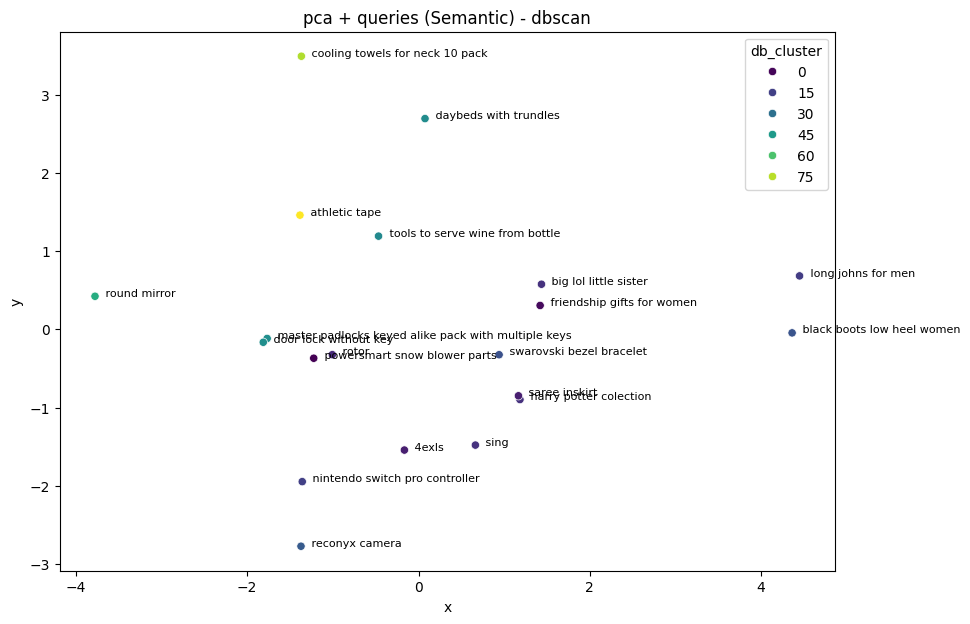

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['db_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=412)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    
)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize='small')
axes[0].set_title("dbscan Semantic Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("dbscan Semantic Clustering - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=308)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='db_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['db_cluster'].unique():
    cluster_points = sample[sample['db_cluster'] == cluster].head(6)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries (Semantic) - dbscan")
plt.show()

### hdbscan

In [ ]:
import optuna
import hdbscan
import numpy as np

def objective(trial):
    # Define the ranges for the "best" parameters
    mcs = trial.suggest_int('min_cluster_size', 40, 300)
    ms = trial.suggest_int('min_samples', 1, 50)
    ep = trial.suggest_float('epsilon', 0.0, 0.3)
    
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=ms,
        cluster_selection_epsilon=ep,
        cluster_selection_method='leaf',
        core_dist_n_jobs=-1
    )
    
    labels = clusterer.fit_predict(x) # Use your UMAP-reduced data
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = (labels == -1).sum() / len(labels)
    
    # Penalty if there are too few clusters or too much noise
    if n_clusters < 40 or noise_pct > 0.30:
        return -1.0
    
    # We use a sample for speed to calculate the DBCV score
    try:
        idx = np.random.choice(len(x), 5000, replace=False)
        score = hdbscan.validity.validity_index(x.values[idx].astype(np.float64), labels[idx])
    except:
        score = -1
        
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) # 30 trials is usually enough to find the peak

print("Best Parameters:", study.best_params)

In [12]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=104,    
    min_samples=1,     
    cluster_selection_epsilon=0.23,  
)

labels_hdb = clusterer.fit_predict(x)

data['hdbscan_cluster'] = labels_hdb

print(data['hdbscan_cluster'].value_counts())

for c in sorted(data['hdbscan_cluster'].unique()):
    print(f"\n HDBscan Cluster {c} ---")
    print(data[data['hdbscan_cluster'] == c]['query'].head(5).tolist())

hdbscan_cluster
-1     12882
 85     4015
 88     1960
 76     1612
 90     1328
       ...  
 49      113
 79      112
 86      110
 67      109
 29      106
Name: count, Length: 92, dtype: int64

 HDBscan Cluster -1 ---
['bird seed', '60 lashes', 'tumblers bulk wholesale', 'carhartt lined cap', 'bronze toilet paper holder']

 HDBscan Cluster 0 ---
['10 lb resistance band without handles', 'sensory bands', 'iphone watch series 3 bands for women', 'casio watch vintage rose gold', 'timex q watches for men']

 HDBscan Cluster 1 ---
['vanity table without mirror with drawers', 'bathroom mirrors only', '03 dodge tow mirrors without spot mirror', 'mirror art', 'baby mirror']

 HDBscan Cluster 2 ---
['colorful towel hooks for bathrooms', 'travel towel', 'bounty essentials paper towel', 'extra large dish drainer and tray', 'towel rack']

 HDBscan Cluster 3 ---
['seat belt belt', 'phone hand strap', 'ukulele kids', 'b low the belt womens belt', '1 in. mens western belts leather without buckle'

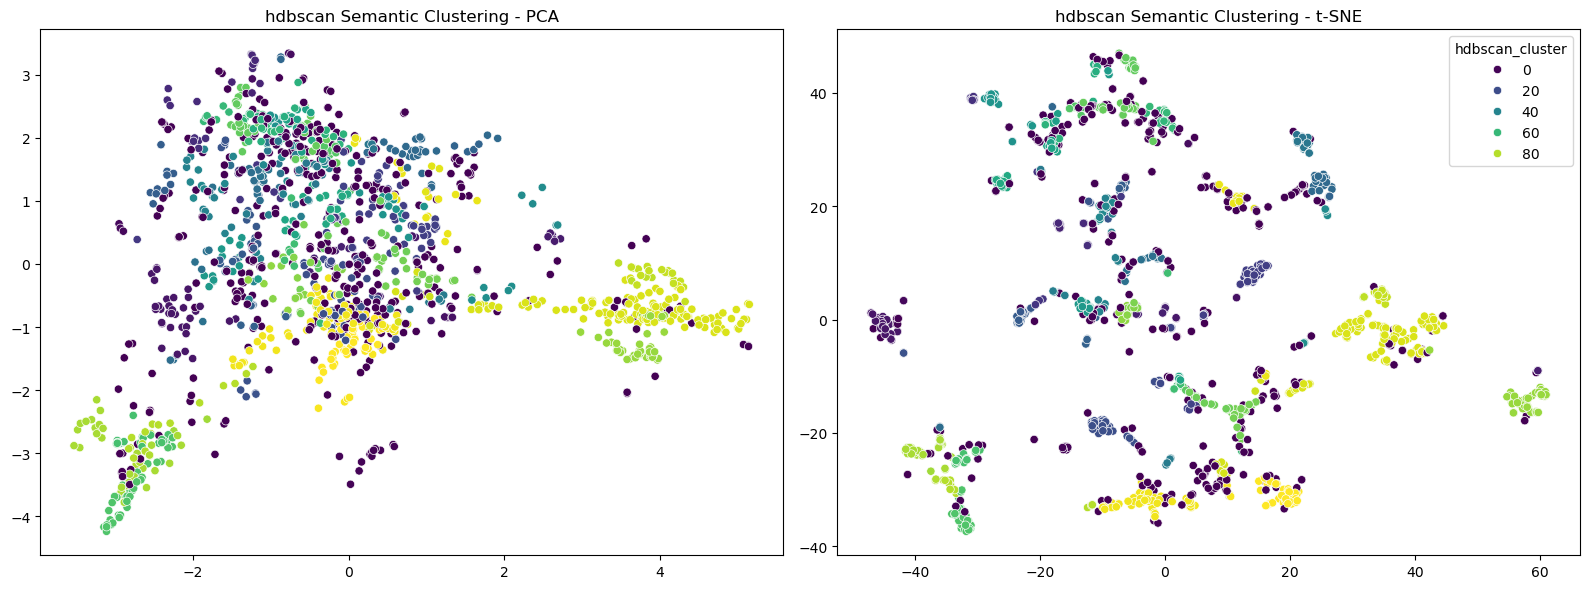

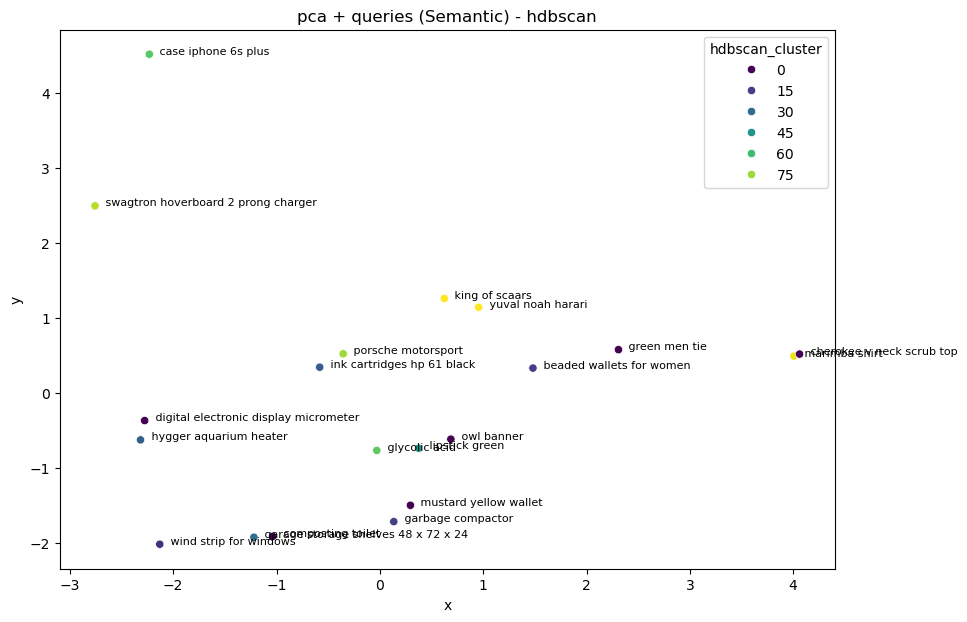

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

#to reduce size of showing graphes
sample_idx = np.random.choice(len(x), 1500, replace=False)
x_sample = x.iloc[sample_idx]
cluster_sample = data.iloc[sample_idx]['hdbscan_cluster']

pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_sample)


tsne = TSNE(n_components=2, perplexity=30, random_state=1)
X_tsne = tsne.fit_transform(x_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[0],
    legend=False
)
axes[0].set_title("hdbscan Semantic Clustering - PCA")

sns.scatterplot(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    hue=cluster_sample,
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title("hdbscan Semantic Clustering - t-SNE")

plt.tight_layout()
plt.show()


# part2 with querise

sample = data.sample(n=20, random_state=81)
x_sample = x.iloc[sample.index]

X_pca = pca.fit_transform(x_sample)
sample['x'] = X_pca[:,0]
sample['y'] = X_pca[:,1]

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=sample,
    x='x',
    y='y',
    hue='hdbscan_cluster',
    palette='viridis'
)

# show only 2–3 labels per cluster
for cluster in sample['hdbscan_cluster'].unique():
    cluster_points = sample[sample['hdbscan_cluster'] == cluster].head(6)
    for _, row in cluster_points.iterrows():
        plt.text(row['x'], row['y'], "   "+row['query'], fontsize=8)

plt.title("pca + queries (Semantic) - hdbscan")
plt.show()

### evaluating

In [ ]:
from sklearn.metrics import silhouette_score , calinski_harabasz_score , davies_bouldin_score
import numpy as np

In [ ]:
#to calculate silhout scor fast
sample_idx = np.random.choice(len(x), size=15000, replace=False)
X_sample = x.iloc[sample_idx].values

models = {
    "kmeans": data['kmeans_cluster'],
    "gmm": data['gmm_cluster'],
    "dbscan": data['db_cluster'],
    "hdbscan": data['hdbscan_cluster']
}

results = []

for name, column in models.items():
    
    labels = column.values
    X_values = x.values
    
    # noise remove dbscan and hdb
    mask = labels != -1
    
    # less clusters
    if len(set(labels[mask])) < 2:
        continue

    #  silhouette on 5k sam
    labels_sample = labels[sample_idx]
    mask_sample = labels_sample != -1
    
    if len(set(labels_sample[mask_sample])) > 1:
        sil = silhouette_score(
            X_sample[mask_sample],
            labels_sample[mask_sample]
        )
    else:
        sil = np.nan

    
    ch = calinski_harabasz_score(X_values[mask], labels[mask])
    db = davies_bouldin_score(X_values[mask], labels[mask])

    results.append({
        "model": name,
        "silhouette": sil,
        "calinski_harabasz": ch,
        "davies_bouldin": db,
        "n_clusters": len(set(labels[mask]))
    })

results_df = pd.DataFrame(results)
print(results_df)

     model  silhouette  calinski_harabasz  davies_bouldin  n_clusters
0   kmeans    0.362565        9247.886057        1.049929          80
1      gmm    0.320472        7907.385468        1.134657          85
2   dbscan    0.228124        2527.684726        0.857322         134
3  hdbscan    0.387135        7240.161937        0.936724          91
